<a href="https://colab.research.google.com/github/EgemenYapucu/DataScienceExercises/blob/main/ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install eli5

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 216 kB 6.7 MB/s 
     |████████████████████████████████| 133 kB 46.0 MB/s 
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107748 sha256=c579b6ee5d3c99860fcb444e30d75a3e7ab4184f0b6167f72b8306a787b317eb
  Stored in directory: /root/.cache/pip/wheels/cc/3c/96/3ead31a8e6c20fc0f1a707fde2e05d49a80b1b4b30096573be
Successfully built eli5
  Attempting uninstall: jinja2
    Found existing installation: Jinja2 2.11.3
    Uninstalling Jinja2-2.11.3:
      Successfully uninstalled Jinja2-2.11.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flask 1.1.4 requires Jinja2<3.0,>=2.10.1, but you have jinja2 3.1.2 which is incompatible.
datascience 0.10.6 requires folium==0.2.1, but you have folium 0.8.3 which is inco

In [ ]:
!pip install shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 569 kB 7.6 MB/s 


In [ ]:
!pip install xgboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
#Egemen Yapucu
#18120205027
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn import metrics
import shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer

In [ ]:
#Soru 0: veriyi yükleyin ve gerekli yerlerde random_state kullanın ki
#kodunuzun sonucu, sonrasında değişmesin.

np.random_state = 17

url = 'https://drive.google.com/file/d/1969fKeE97icCMqZMLMPQLMoPXt9e34c2/view?usp=sharing'
url1 = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#Soru 1:Data'nın büyüklüğünü bulun.

df.size # Direkt dataframenin büyüklüğünü hesaplıyor toplam eleman sayısını

10692

In [ ]:
#Soru 2:Data'nın nasıl göründüğünü gösterin. (İlk 5 satır veya son 5 satır)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Soru 3: Data'nın sütunlarında hangi veri türleri bulunmaktadır?

df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [ ]:
#Soru 4: Hangi sütunda, kaç tane eksik verimiz var?

df['PassengerId'].isnull().sum()#PassengerId sütunu için null değer hesaplaması

0

In [ ]:
df['Survived'].isnull().sum()#Survived sütunu için null değer hesaplaması

0

In [ ]:
df['Pclass'].isnull().sum()#Pclass sütunu için null değer hesaplaması

0

In [ ]:
df['Name'].isnull().sum()#Name sütunu için null değer hesaplaması

0

In [ ]:
df['Sex'].isnull().sum()#Sex sütunu için null değer hesaplaması

0

In [ ]:
df['Age'].isnull().sum()#Age sütunu için null değer hesaplaması

177

In [ ]:
df['SibSp'].isnull().sum()#SibSp sütunu için null değer hesaplaması

0

In [ ]:
df['Parch'].isnull().sum()#Parch sütunu için null değer hesaplaması

0

In [ ]:
df['Ticket'].isnull().sum()#Ticket sütunu için null değer hesaplaması

0

In [ ]:
df['Fare'].isnull().sum()#Fare sütunu için null değer hesaplaması

0

In [ ]:
df['Cabin'].isnull().sum()#Cabin sütunu için null değer hesaplaması

687

In [ ]:
df['Embarked'].isnull().sum()#Embarked sütunu için null değer hesaplaması

2

In [ ]:
#Soru 5:Verimizin count, mean, std. dev, quartile gibi özelliklerini gösterin.

df.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [ ]:
df.mean()

Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.


PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

In [ ]:
df.std()

Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.


PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             14.526497
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64

In [ ]:
df.median()

Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.


PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

In [ ]:
df.mode()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3.0,"Abbing, Mr. Anthony",male,24.0,0.0,0.0,1601,8.05,B96 B98,S
1,2,NaN,NaN,"Abbott, Mr. Rossmore Edward",NaN,NaN,NaN,NaN,347082,NaN,C23 C25 C27,NaN
2,3,NaN,NaN,"Abbott, Mrs. Stanton (Rosa Hunt)",NaN,NaN,NaN,NaN,CA. 2343,NaN,G6,NaN
3,4,NaN,NaN,"Abelson, Mr. Samuel",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,"Abelson, Mrs. Samuel (Hannah Wizosky)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,NaN,NaN,"de Mulder, Mr. Theodore",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
887,888,NaN,NaN,"de Pelsmaeker, Mr. Alfons",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
888,889,NaN,NaN,"del Carlo, Mr. Sebastiano",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889,890,NaN,NaN,"van Billiard, Mr. Austin Blyler",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Soru 6:Verimizde inconsistent data entry var mı, kontrol edin.
df['Name'] = df['Name'].str.lower()#Büyük harfleri küçülttük
df['Name'] = df['Name'].str.strip()#Boşlukları attık
Name = df['Name'].unique()#Sadece kendine özgü stringleri seriye aldık
Name.sort()#Sort ettik ve yazdırdık
Name

array(['abbing, mr. anthony', 'abbott, mr. rossmore edward',
       'abbott, mrs. stanton (rosa hunt)', 'abelson, mr. samuel',
       'abelson, mrs. samuel (hannah wizosky)',
       'adahl, mr. mauritz nils martin', 'adams, mr. john',
       'ahlin, mrs. johan (johanna persdotter larsson)',
       'aks, mrs. sam (leah rosen)', 'albimona, mr. nassef cassem',
       'alexander, mr. william', 'alhomaki, mr. ilmari rudolf',
       'ali, mr. ahmed', 'ali, mr. william',
       'allen, miss. elisabeth walton', 'allen, mr. william henry',
       'allison, master. hudson trevor', 'allison, miss. helen loraine',
       'allison, mrs. hudson j c (bessie waldo daniels)',
       'allum, mr. owen george',
       'andersen-jensen, miss. carla christine nielsine',
       'anderson, mr. harry', 'andersson, master. sigvard harald elias',
       'andersson, miss. ebba iris alfrida',
       'andersson, miss. ellis anna maria',
       'andersson, miss. erna alexandra',
       'andersson, miss. ingeborg con

In [ ]:
df['Sex'] = df['Sex'].str.lower()#Büyük harfleri küçülttük
df['Sex'] = df['Sex'].str.strip()#Boşlukları attık
Sex = df['Sex'].unique()#Sadece kendine özgü stringleri seriye aldık
Sex.sort()#Sort ettik ve yazdırdık
Sex

array(['female', 'male'], dtype=object)

In [ ]:
df['Ticket'] = df['Ticket'].str.lower()#Büyük harfleri küçülttük
df['Ticket'] = df['Ticket'].str.strip()#Boşlukları attık
Ticket = df['Ticket'].unique()#Sadece kendine özgü stringleri seriye aldık
Ticket.sort()#Sort ettik ve yazdırdık
Ticket

array(['110152', '110413', '110465', '110564', '110813', '111240',
       '111320', '111361', '111369', '111426', '111427', '111428',
       '112050', '112052', '112053', '112058', '112059', '112277',
       '112379', '113028', '113043', '113050', '113051', '113055',
       '113056', '113059', '113501', '113503', '113505', '113509',
       '113510', '113514', '113572', '113760', '113767', '113773',
       '113776', '113781', '113783', '113784', '113786', '113787',
       '113788', '113789', '113792', '113794', '113796', '113798',
       '113800', '113803', '113804', '113806', '113807', '11668', '11751',
       '11752', '11753', '11755', '11765', '11767', '11769', '11771',
       '11774', '11813', '11967', '12233', '12460', '12749', '13049',
       '13213', '13214', '13502', '13507', '13509', '13567', '13568',
       '14311', '14312', '14313', '14973', '1601', '16966', '16988',
       '17421', '17453', '17463', '17464', '17465', '17466', '17474',
       '17764', '19877', '19928', '19943

In [ ]:
#Verimizi inceledikten sonra görüyoruz biribiriyle eşleşen farklı yazım
#hatalarından veya boşluklardan oluşan bir çakışma bulunmamakta

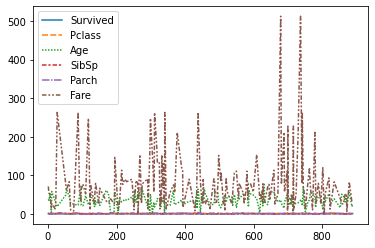

In [ ]:
#Soru 7: Kategorik ve sayısal veriler için gerekli görsellerden çıkarım yapın.
dfn = df #Verimizn bir kopyasını oluşturduk.
dfn = dfn.drop('PassengerId', axis = 1) #Kopya üzerinde verinin içinde plot edilirken olmasını istemediğimiz sütunu çıkartıyoruz.
dfn = dfn.dropna() #Ardından NaN değerleri drop ediyoruz ki daha düzgün bir plot elde edelim
sns.lineplot(data=dfn)#Bütün veriyi çizgi grafik olarak çizdirdim başlangoç olarak

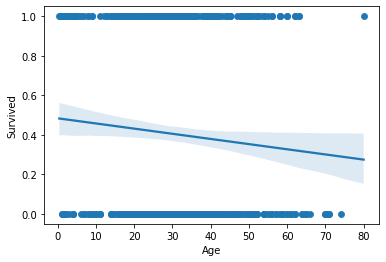

In [ ]:
sns.scatterplot(x = df['Age'], y = df['Survived'])
sns.regplot(x = df['Age'], y = df['Survived'])#Burda amacımız yaşlara göre insanların ne kadar kurtulduğuyla ilgili fikir almak
#Yaşlılar daha az kurtulmuşken yaşı daha genç olanların kurtulması daha olası imiş.

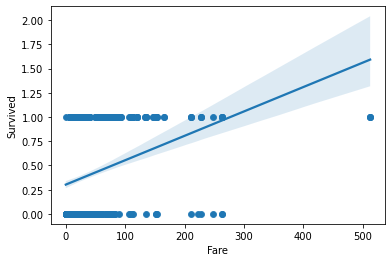

In [ ]:
sns.scatterplot(x = df['Fare'], y = df['Survived']) #Alınan biletin fiyatına göre kurtulma durumumuz nedir bunu yorumlamak istiyoruz.
sns.regplot(x = df['Fare'], y = df['Survived']) #Daha çok para ödeyenleri kurtulma oranı çok daha yüksek gibi görünüyor.

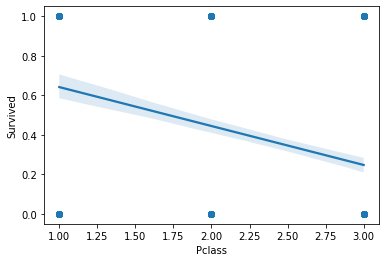

In [ ]:
sns.scatterplot(x = df['Pclass'], y = df['Survived'])# Bilet sınıfına göre kurtulma oranınına bakıcaz
sns.regplot(x = df['Pclass'], y = df['Survived']) # Bilet sınıfı daha yüksek olan yolcularda kurtulma oranı daha düşük göründüğü gibi

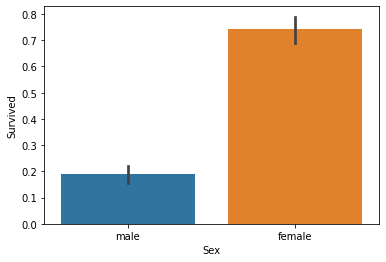

In [ ]:
sns.barplot(x=df['Sex'],y=df['Survived'])# Cinsiyetlere göre kurtulanların sayısını elde etmek istiyoruz burada
#Kadınların sayısı daha az olmalarına rağmen neredeyse 4x daha fazla kurtulmuşlar.

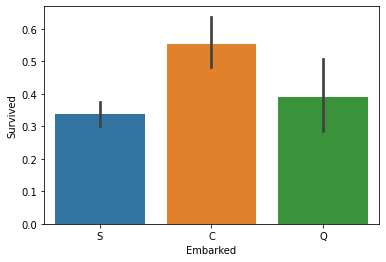

In [ ]:
sns.barplot(x=df['Embarked'],y=df['Survived'])# Kurtulan insanların nereli olduğuna göre veriyi yorumluyoruz
#Kurtulan insanların çoğu Cherbourg'dan gelmişken Queenstown 2. sırada yer alıyor ve Southamptondan binen insanlar arasından kurtulanlar en az sayıda

In [ ]:
#Soru 8:Eksik verilerimiz için gerekli imputationları yapın.
df = df.drop('Cabin',axis = 1) #Cabin datasını kullanmıyıcaz onun için drop ediyoruz.

a = df.drop('Name',axis = 1) # Dataframein bir kopyasını oluşturuyoruz bu sayede verimizi kaybetmiyoruz.
a = a.drop('Sex',axis = 1) # Kullanıcağımız imputer için gereksiz kolonları drop ediyoruz.
a = a.drop('Ticket',axis = 1)
a = a.drop('Embarked', axis = 1)
imputer = SimpleImputer(missing_values=np.NaN) # imputer tanımlıyoruz.
idf=pd.DataFrame(imputer.fit_transform(a))
idf.columns=a.columns
idf.index=a.index

df['Age'] = idf['Age'] # Yeni oluşturduğumuz kolonu df'e gönderiyoruz.

df = df.dropna() # Ardından embarked kolonumuzda 2 adet nan değerimiz vardı
                # sonucu çok değiştirmeyeceği için drop ettik.
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
#Soru 9:Eğer inconsistent data entry varsa, düzeltin.
#soru 6'da bakmıştık herhangi bir problem görmedik bundan dolayı herhangi bir
#düzeltme yapmamıza gerek yok.

In [ ]:
#Soru 10: Kategorik değişkenleri, sayısal hale getirin.
df['Sex'].replace(['female','male'],[1,2],inplace=True)# female = 1, male = 2
df['Embarked'].replace(['S','C','Q'],[1,2,3],inplace=True)# S=1, C=2, Q=3

In [ ]:
df['Sex']

0      2
1      1
2      1
3      1
4      2
      ..
886    2
887    1
888    1
889    2
890    2
Name: Sex, Length: 889, dtype: int64

In [ ]:
df['Embarked']

0      1
1      2
2      1
3      1
4      1
      ..
886    1
887    1
888    1
889    2
890    3
Name: Embarked, Length: 889, dtype: int64

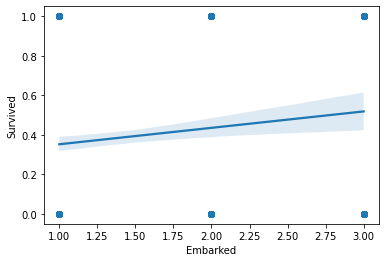

In [ ]:
sns.scatterplot(x = df['Embarked'], y = df['Survived'])#Değişkenimiz kategorik olduğu için regression plotuna bakamamıştık
sns.regplot(x = df['Embarked'], y = df['Survived'])#Şimdi kurtulanların sayısının hangi durumlarda nasıl değiştiğine daha rahat bakabiliriz.

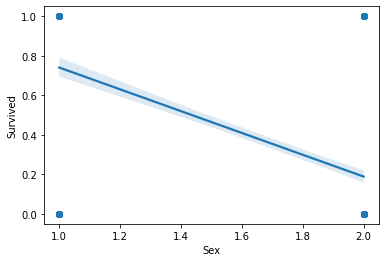

In [ ]:
sns.scatterplot(x = df['Sex'], y = df['Survived'])
sns.regplot(x = df['Sex'], y = df['Survived'])

In [ ]:
#Soru 11: Kendi sezginize göre yeni özellik değişkenleri yaratın.
df['AFRatio'] = df['Fare'] / df['Age'] #Ödenen tutar ile yaş arasındaki ilişkiden ortaya çıkar.
df['PcFRatio'] = df['Fare'] / df['Pclass'] #Ödenen tutarın seyahat edilen sınıfa bölümünü ifade eder.

In [ ]:
#Soru 12: Mutual information skorlarına bakın.
X = df.copy()
y = X.pop("Survived")

for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

discrete_features = X.dtypes == float

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::]

PcFRatio       0.656270
Fare           0.649498
AFRatio        0.379168
Sex            0.129085
Ticket         0.087817
SibSp          0.068799
Parch          0.048076
Age            0.042783
Name           0.017571
Pclass         0.010820
PassengerId    0.010737
Embarked       0.000000
Name: MI Scores, dtype: float64

In [ ]:
#Skorlardan anlayacağımız üzere hedef feature ile aralarındaki ilişkiye bakarsak,
#oluşturduğumuz yeni featurelar diğer birçok featuredan çok daha etkili olmuşlar.
#PcFRatio,Fare ve AFRatio'dan beklediğimiz ilişkileri görmüşüz
#Age ve Sex featureları ise beklentimizi karşılayamamış.

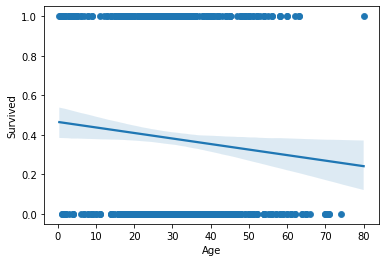

In [ ]:
#Soru 13:Şimdi tekrar 7. Adımdaki gibi, aslında sezginize göre mantıklı
#olması gereken, ancak iyi mutual information score vermeyen, değişkenlerin,
#tek başına hedef değişkenle veya başka değişkenlerle etkileşim halinde hedef
#değişkenle olan plotlarını çizdirin.

sns.scatterplot(x = df['Age'], y = df['Survived'])
sns.regplot(x = df['Age'], y = df['Survived'])

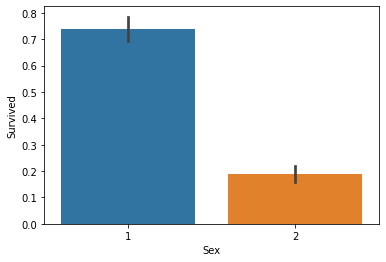

In [ ]:
sns.barplot(x=df['Sex'],y=df['Survived'])

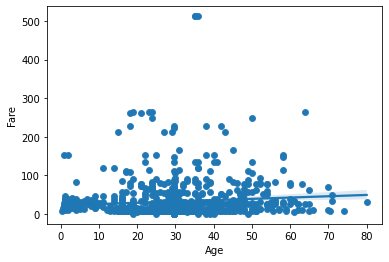

In [ ]:
sns.scatterplot(x = df['Age'], y = df['Fare'])
sns.regplot(x = df['Age'], y = df['Fare'])

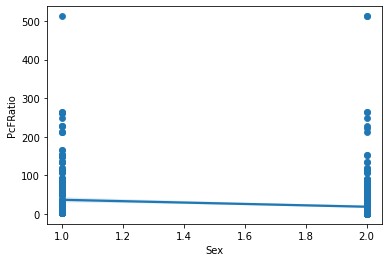

In [ ]:
sns.scatterplot(x = df['Sex'], y = df['PcFRatio'])
sns.regplot(x = df['Sex'], y = df['PcFRatio'])

In [ ]:
#Soru 14:K-means clustering ile var olan değişkenlerden faydalanarak yeni
#değişkenler yaratabiliyorsanız yaratın. tek başına hedef değişkenle olan
#plotlarını çizdirin.
features = ['PassengerId','Pclass','Name','Sex','Age','SibSp',
            'Parch','Ticket','Fare','Embarked','AFRatio','PcFRatio']
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
kmeans = KMeans(n_clusters=6, n_init=10, random_state=1)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AFRatio,PcFRatio,Cluster
0,1,3,0,2,22.0,1,0,0,7.2500,1,0.329545,2.416667,4
1,2,1,1,1,38.0,1,0,1,71.2833,2,1.875876,71.283300,4
2,3,3,2,1,26.0,0,0,2,7.9250,1,0.304808,2.641667,4
3,4,1,3,1,35.0,1,0,3,53.1000,1,1.517143,53.100000,4
4,5,3,4,2,35.0,0,0,4,8.0500,1,0.230000,2.683333,4


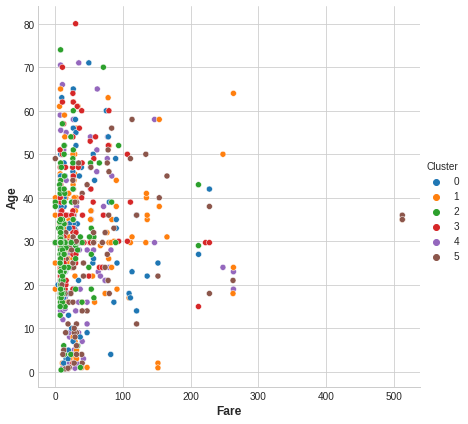

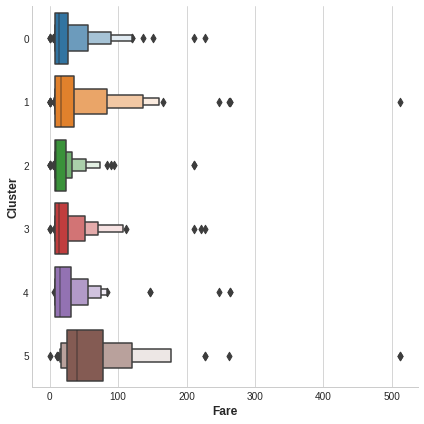

In [ ]:
sns.relplot(x="Fare", y="Age", hue="Cluster", data=X, height=6,)

sns.catplot(x="Fare", y="Cluster", data=X, kind="boxen", height=6);

In [ ]:
#Soru 15:Principle component analysis ile değişkenlerimizi daha anlamlı hale
#getirebiliyor isek, yeni değişkenleri modele ekleyin. tek başına hedef
#değişkenle olan plotlarını çizdirin.

X = df.copy()# Dataframeyi kopyaladık ki veriler boşa gitmesin
y = X.pop('Survived') # hedef özelliğimizi ayırıyoruz diğer özelliklerden
X = X.loc[:, features]

for colname in X.select_dtypes("object"):# Her bir objeyi floata çevirmemiz lazım
    X[colname], _ = X[colname].factorize()# ki bu sayede nümerik işlemleri yapalım

discrete_features = X.dtypes == float

X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)# Featureları scale ediyoruz
pca = PCA()
X_pca = pca.fit_transform(X_scaled)# PCA uyguluyoruz

component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=component_names)

X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,1.465689,-2.747137,-0.377686,0.863379,0.342663,0.197746,-0.660859,-0.073264,0.114443,0.097669,-0.088463,-0.001734
1,3.195760,-0.190169,-1.759279,-1.123899,-0.321723,-0.232975,-0.190968,1.025545,-0.311757,0.048465,-0.039159,-0.001639
2,1.611801,-2.483162,-0.636987,-0.385906,-0.358226,-1.431064,-0.373683,-0.106837,0.673147,0.297792,-0.037624,-0.001722
3,2.893640,-0.570518,-1.440158,0.072277,-0.861995,-1.046212,-0.439662,1.036061,-0.306412,0.101243,-0.056647,-0.001710
4,1.180456,-2.574615,-1.277651,0.841422,0.133414,0.054880,0.076405,-0.385431,0.511982,0.297363,-0.038448,-0.001741


In [ ]:
PCS = pd.DataFrame(pca.components_.T,  # Matrisin tanspozu
    columns=component_names,  # PClerin sütunlar
    index=X.columns,  # Ve özelliklerin yüklenmesi
)
PCS

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
PassengerId,-0.404885,0.382422,0.240638,-0.039017,-0.059776,0.067034,-0.019249,-0.014045,-0.030077,0.347347,-0.014295,7.071061e-01
Pclass,-0.188553,-0.390364,0.301360,-0.122713,0.092809,0.162787,-0.106442,-0.370837,0.721634,0.012087,-0.036358,-6.389777e-07
Name,-0.404875,0.382437,0.240626,-0.039065,-0.059757,0.067052,-0.019257,-0.014050,-0.030078,0.347344,-0.014237,-7.071075e-01
Sex,-0.178439,-0.092453,-0.141262,0.569912,0.383539,0.612424,0.064858,-0.198713,-0.220447,-0.020048,-0.000479,-6.128853e-06
Age,-0.065666,0.134648,-0.497682,0.052673,-0.441182,0.289785,0.461587,0.203734,0.435444,0.065529,-0.001630,-2.509835e-06
SibSp,0.222682,-0.013679,0.444829,0.078334,-0.263535,0.483718,-0.316443,0.560221,0.044516,-0.156458,-0.048353,-4.322903e-06
Parch,0.236974,0.069493,0.449908,-0.000376,-0.365288,0.116662,0.526052,-0.466583,-0.227402,-0.207540,-0.018358,-6.183780e-06
Ticket,-0.462226,0.283576,0.021018,-0.013765,0.083649,-0.098279,0.016014,0.075749,0.089659,-0.820650,0.033832,2.924751e-06
Fare,0.350254,0.450704,-0.067264,0.017496,0.074728,0.113957,-0.240942,-0.239543,0.208166,-0.024754,0.701004,4.039711e-05
Embarked,0.032086,0.013420,-0.091264,-0.781368,0.349999,0.439570,0.180772,0.062450,-0.163641,-0.027874,0.008399,3.716828e-05


In [ ]:
mi_scores = make_mi_scores(X_pca, y, discrete_features=False)
mi_scores
#Sonuçlardan göründüğü gibi hedef değişkenle en alakalı PC4 ancak bir önceki mi
#testimizde yarattığım yeni değişkenler çok daha alakalı olduğundan yeni bir de-
#ğişken almıyoruz.

PC4     0.158438
PC6     0.116746
PC2     0.063835
PC5     0.042783
PC8     0.039793
PC11    0.031479
PC1     0.017692
PC7     0.008409
PC12    0.008064
PC10    0.005428
PC3     0.003541
PC9     0.002940
Name: MI Scores, dtype: float64

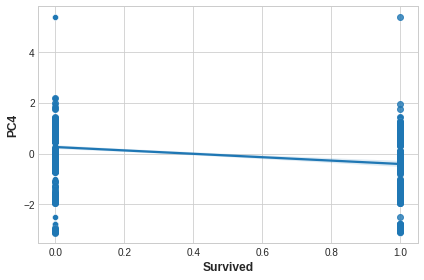

In [ ]:
sns.scatterplot(x = df['Survived'], y = X_pca['PC4'])
sns.regplot(x = df['Survived'], y = X_pca['PC4'])

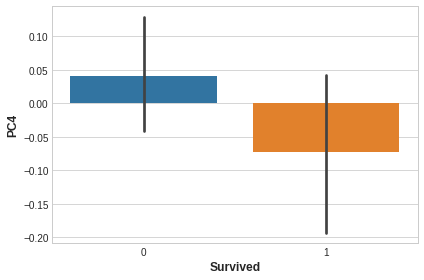

In [ ]:
sns.barplot(x = df['Survived'], y= X_pca['PC4'])

In [ ]:
#Soru 16:İlk naif modelimizi oluşturun.

A = X.loc[:, features]#Modelimiz için verimizi hedef özellik ve diğer özellikler olarak ikiye ayırdık
b = df.loc[:, ['Survived']]

A_train, A_test, b_train, b_test = train_test_split(A, b, test_size = 0.30)# train test verimizi ayırdık

RFC = RandomForestClassifier(n_estimators = 100, random_state=17)#modelimizi tanımladık

RFC.fit(A_train, b_train)#train edildi

b_pred = RFC.predict(A_test)#test edildi

acc = metrics.accuracy_score(b_test, b_pred)#accuracy hesaplandı
acc


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


0.8277153558052435

In [ ]:
#Soru 17:Permutation importance'larına bakın.

perm = PermutationImportance(RFC, random_state=1).fit(A_test, b_test)
eli5.show_weights(perm, feature_names = A_test.columns.tolist())

#Sex değişkeni en etkili feature olarak görünürken embarked bir o kadar etkisiz görünüyor.

Weight,Feature
0.1685 ± 0.0303,Sex
0.0225 ± 0.0150,Pclass
0.0105 ± 0.0248,AFRatio
0.0097 ± 0.0102,Age
0.0060 ± 0.0037,Parch
0.0007 ± 0.0129,PassengerId
0.0000 ± 0.0082,Embarked
0.0000 ± 0.0125,SibSp
-0.0037 ± 0.0134,PcFRatio
-0.0082 ± 0.0160,Name


In [ ]:
#Soru 18:SHAP değerlerine bakın.Bunları yorumlayın.
pred_data = A_test.iloc[:12]
RFC.predict_proba(pred_data)

array([[0.89, 0.11],
       [0.96, 0.04],
       [0.88, 0.12],
       [0.79, 0.21],
       [0.68, 0.32],
       [0.36, 0.64],
       [0.99, 0.01],
       [0.63, 0.37],
       [0.92, 0.08],
       [0.44, 0.56],
       [0.74, 0.26],
       [0.71, 0.29]])

In [ ]:
#Herbir özelliğimizin survive hedef özelliğimize etkilerini görüyoruz.
#PassengerId = %2
#Pclass = %18
#Name = %22
#Sex = %47
#Age = %89
#SibSp = %02
#Parch = %18
#Ticket = %22
#Fare = %22
#Embarked = %16
#AFRatio = %18
#PcFRatio = %96
#Not: Bir önceki çalıştırmama göre değişiklik gösterdiğinden hocam bu şekilde yazdım
#bir önceki değerleri.

In [ ]:
explainer = shap.TreeExplainer(RFC)
shap_values = explainer.shap_values(pred_data)
shap_values

[array([[ 8.87144301e-03,  2.59303647e-02,  1.22268634e-02,
          1.08179081e-01, -1.48576924e-02, -4.53724821e-03,
          5.79224147e-04,  8.79200435e-04,  3.83396404e-02,
          9.96607077e-03,  4.95880728e-02,  3.79217965e-02],
        [ 9.28806450e-03,  1.80914847e-02,  2.14131131e-02,
          1.54826308e-01,  2.07812631e-02, -5.13939032e-03,
         -1.43033042e-04, -5.05612355e-03,  2.32316274e-02,
         -1.09883390e-02,  7.06329836e-02,  4.61488584e-02],
        [ 7.26906371e-03,  1.14901437e-01,  2.40246073e-03,
         -1.13957413e-01, -1.36499624e-02,  9.56331606e-02,
         -1.96644107e-03,  6.07542371e-02,  4.21070505e-02,
          1.18152403e-02,  1.41373608e-03,  5.63642474e-02],
        [-1.86081185e-02,  9.67985837e-03, -2.86558597e-02,
          1.27387191e-01, -2.36196356e-02, -5.95306666e-03,
          3.59772036e-04, -2.35782927e-02,  2.36648962e-02,
          4.66950325e-03,  6.17974934e-02,  4.59430753e-02],
        [ 1.64387714e-02,  5.6222160

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1], pred_data)

In [ ]:
k_explainer = shap.KernelExplainer(RFC.predict_proba, A_train)
k_shap_values = k_explainer.shap_values(pred_data)
shap.force_plot(k_explainer.expected_value[1], k_shap_values[1], pred_data)
#Ne yazık ki görselleştiremedik kernel explainerı

X does not have valid feature names, but RandomForestClassifier was fitted with feature names
Using 622 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/12 [00:00<?, ?it/s]

X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassif

In [ ]:
#Soru 19:Yine yeni özellik adına bir fikir verdiyse kullanın. Mutual information skoruna bakın.
#Bir önceki soruya baktığımız zaman en çok etki eden özelliklerimiz
#Sex, Age, Embarked olduğuna göre.
df['StoA'] = df['Age']/df['Sex'] #Age ve Sex değişkenlerinin ilişkisi aslında o kadar da kötü değilmiş bunu gördük önceki analizlerde
df['EtoA'] = df['Age']/df['Embarked']# Embarked değişkeni de yine etkili özelliklerimizden

In [ ]:
X = df.copy()
y = X.pop("Survived")

for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

discrete_features = X.dtypes == float

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::]

PcFRatio       0.636304
Fare           0.617731
AFRatio        0.506431
StoA           0.420286
EtoA           0.187614
Sex            0.171947
Age            0.096219
Ticket         0.094098
Pclass         0.059871
Parch          0.052212
Name           0.017772
SibSp          0.016105
PassengerId    0.010767
Embarked       0.000000
Name: MI Scores, dtype: float64

In [ ]:
#StoA ve EtoA özelliklerimiz yine oluştukları her iki featuredan da daha anlamlılar.

In [ ]:
#Soru 20:Herhangi bir data leakage endişesi yaşıyor musunuz? Data leakage
#türleri nelerdir ve hangi durumlarda görülür, birer örnek verin.

#Data leakage bizim bu şekilde yaptığımız tahminsel modellerde görülme ihtimali
#yüksek bir durumdur. Ancak elde ettiğim sonuçlara bakacak olursak normalin çok
#üzerinde değerler bulmadım alışılmadık garip bir şey ile karşılaşmadım. Bu sebeplerden
#data leakage olduğunu düşünmüyürum. Data leakage özellikle zaman serisi datasetlerinde
#test train oluştururken, Graf problemlerinde random sampling methods uygularken
#veya ses,görüntü gibi farklı dosyalarda ve time stamplere sahip örneklerin bulunduğu
# durumlarda gerçekleşebilir.Türleri için şöyler diyebiliriz:
# Predictive modellerde oluşanlar.
# Dışarıdan alınmış verinin dışarıdan geldiği durumlarda oluşanlar.
# Makine öğrenemesi yaparken daha iyi sonuç veren modellerde görülebilenler

In [ ]:
#Soru 21: Pipelinelar yaratın.

preproc = StandardScaler()#Ön işlem olarak bir scaler tanımladık

RFR = RandomForestRegressor(n_estimators = 75,random_state=17)#Ardından sonraki sorularda kullanacağımız bazı modelleri oluşturduk.

DCT = DecisionTreeRegressor(random_state=17)

XGb = XGBRegressor(n_estimators=500)

pipeline1 = Pipeline(steps = [('preprocess', preproc),('model', RFR)])#Pipelinelarımızı istendiği gibi oluşturuyoruz
pipeline2 = Pipeline(steps = [('preprocess', preproc),('model', DCT)])
pipeline3 = Pipeline(steps = [('preprocess', preproc),('model', XGb)])

In [ ]:
#Soru 22:Decision Tree modeli ile, pipeline üzerinden cross validation yaparak,
#değişik parametreler deneyerek içlerinden en iyi sonuç vereni bulun.
DCT1 = DecisionTreeRegressor(max_depth=2,random_state=17)
DCT2 = DecisionTreeRegressor(max_depth=4,random_state=17)

pipeline4 = Pipeline(steps = [('preprocess', preproc),('model', DCT1)])
pipeline5 = Pipeline(steps = [('preprocess', preproc),('model',DCT2)])

scores2 = -1 * cross_val_score(pipeline2, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores4 = -1 * cross_val_score(pipeline4,A,b,
                               cv=12,
                               scoring='neg_mean_absolute_error')
scores5 = -1 * cross_val_score(pipeline5,A,b,
                               cv=12,
                               scoring='neg_mean_absolute_error')

In [ ]:
print("MAE scores2:\n", scores2)
print("MAE scores4:\n", scores4)
print("MAE scores5:\n", scores5)

MAE scores2:
 [0.30666667 0.2027027  0.31081081 0.25675676 0.17567568 0.25675676
 0.32432432 0.28378378 0.25675676 0.24324324 0.28378378 0.2027027 ]
MAE scores4:
 [0.33221963 0.30826479 0.29082747 0.30493046 0.25180276 0.27237142
 0.28212196 0.26743151 0.30288979 0.2766418  0.26501556 0.27097967]
MAE scores5:
 [0.31934271 0.26830256 0.25246465 0.30401235 0.25440692 0.22701824
 0.28081967 0.2762182  0.25813553 0.25640795 0.19747996 0.23143554]


In [ ]:
#Soru 23:Random Forest modeli ile, pipeline üzerinden cross validation yaparak,
#değişik parametreler deneyerek içlerinden en iyi sonuç vereni bulun.

RFR1 = RandomForestRegressor(n_estimators = 25, random_state=17)
RFR2 = RandomForestRegressor(n_estimators = 50,random_state=17)
RFR3 = RandomForestRegressor(n_estimators = 100, random_state=17)
RFR4 = RandomForestRegressor(n_estimators = 200, random_state= 17)

pipeline6 = Pipeline(steps = [('preprocess', preproc),('model',RFR)])
pipeline7 = Pipeline(steps = [('preprocess', preproc),('model',RFR1)])
pipeline8 = Pipeline(steps = [('preprocess', preproc),('model',RFR2)])
pipeline9 = Pipeline(steps = [('preprocess', preproc),('model',RFR3)])
pipeline10 = Pipeline(steps = [('preprocess', preproc),('model',RFR4)])

scores1 = -1 * cross_val_score(pipeline1, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores6 = -1 * cross_val_score(pipeline6, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores7 = -1 * cross_val_score(pipeline7,A,b,
                               cv=12,
                               scoring='neg_mean_absolute_error')
scores8 = -1 * cross_val_score(pipeline8,A,b,
                               cv=12,
                               scoring='neg_mean_absolute_error')
scores9 = -1 * cross_val_score(pipeline9, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores10 = -1 * cross_val_score(pipeline10, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')

In [ ]:
print("MAE scores1:\n", scores1)
print("MAE scores6:\n", scores6)
print("MAE scores7:\n", scores7)
print("MAE scores8:\n", scores8)
print("MAE scores9:\n", scores9)
print("MAE scores10:\n", scores10)

MAE scores1:
 [0.3328     0.24954955 0.27171171 0.29801802 0.21495495 0.22954955
 0.27153153 0.25045045 0.20954955 0.24612613 0.2190991  0.20576577]
MAE scores6:
 [0.3328     0.24954955 0.27171171 0.29801802 0.21495495 0.22954955
 0.27153153 0.25045045 0.20954955 0.24612613 0.2190991  0.20576577]
MAE scores7:
 [0.33653333 0.24324324 0.28702703 0.30054054 0.21135135 0.23621622
 0.27675676 0.25837838 0.20756757 0.25459459 0.23027027 0.21135135]
MAE scores8:
 [0.33093333 0.24810811 0.27432432 0.29837838 0.21486486 0.22702703
 0.27540541 0.24783784 0.20891892 0.23945946 0.21837838 0.20972973]
MAE scores9:
 [0.3344     0.24851351 0.26824324 0.29905405 0.22067568 0.22472973
 0.27297297 0.24945946 0.21310811 0.25148649 0.2222973  0.21081081]
MAE scores10:
 [0.33646667 0.24554054 0.26912162 0.29695946 0.22054054 0.22817568
 0.27560811 0.24277027 0.21554054 0.25966216 0.22405405 0.21013514]


In [ ]:
#Soru 24:XGBoost modeli ile, pipeline üzerinden cross validation yaparak,
#değişik parametreler deneyerek içlerinden en iyi sonuç vereni bulun.

XGb1 = XGBRegressor(n_estimators=500, learning_rate=0.1)
XGb2 = XGBRegressor(n_estimators=500, learning_rate=0.05)
XGb3 = XGBRegressor(n_estimators=1000, learning_rate=0.1)
XGb4 = XGBRegressor(n_estimators=1000, learning_rate=0.05)
XGb5 = XGBRegressor(n_estimators=500, learning_rate=0.2)

pipeline11 = Pipeline(steps = [('preprocess', preproc),('model',XGb)])
pipeline12 = Pipeline(steps = [('preprocess', preproc),('model',XGb1)])
pipeline13 = Pipeline(steps = [('preprocess', preproc),('model',XGb2)])
pipeline14 = Pipeline(steps = [('preprocess', preproc),('model',XGb3)])
pipeline15 = Pipeline(steps = [('preprocess', preproc),('model',XGb4)])
pipeline16 = Pipeline(steps = [('preprocess', preproc),('model',XGb5)])

scores3 = -1 * cross_val_score(pipeline3, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores11 = -1 * cross_val_score(pipeline11, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores12 = -1 * cross_val_score(pipeline12,A,b,
                               cv=12,
                               scoring='neg_mean_absolute_error')
scores13 = -1 * cross_val_score(pipeline13,A,b,
                               cv=12,
                               scoring='neg_mean_absolute_error')
scores14 = -1 * cross_val_score(pipeline14, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores15 = -1 * cross_val_score(pipeline15, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')
scores16 = -1 * cross_val_score(pipeline16, A, b,
                              cv=12,
                              scoring='neg_mean_absolute_error')

[15:06:26] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:27] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:28] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:29] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:30] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:31] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:32] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[15:06:32] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of re

In [ ]:
print("MAE scores3:\n", scores3)
print("MAE scores11:\n", scores11)
print("MAE scores12:\n", scores12)
print("MAE scores13:\n", scores13)
print("MAE scores14:\n", scores14)
print("MAE scores15:\n", scores15)
print("MAE scores16:\n", scores16)

MAE scores3:
 [0.32389287 0.24610828 0.27285559 0.32275904 0.24838472 0.26957842
 0.26741305 0.25459063 0.23299266 0.29833633 0.23137863 0.23332339]
MAE scores11:
 [0.32389287 0.24610828 0.27285559 0.32275904 0.24838472 0.26957842
 0.26741305 0.25459063 0.23299266 0.29833633 0.23137863 0.23332339]
MAE scores12:
 [0.32389287 0.24610828 0.27285559 0.32275904 0.24838472 0.26957842
 0.26741305 0.25459063 0.23299266 0.29833633 0.23137863 0.23332339]
MAE scores13:
 [0.31361088 0.25871022 0.27134749 0.31767774 0.23610687 0.25358581
 0.26906319 0.24905661 0.24342763 0.28682863 0.21151495 0.21362099]
MAE scores14:
 [0.34288566 0.24455255 0.28698427 0.32750092 0.2577718  0.30949611
 0.2591351  0.25920711 0.22739105 0.30937056 0.24736808 0.25354743]
MAE scores15:
 [0.32072397 0.25619302 0.28232141 0.31933073 0.24787585 0.26833999
 0.26282482 0.25248431 0.23108612 0.30164196 0.21518394 0.22998483]
MAE scores16:
 [0.39834878 0.26232363 0.30507771 0.3486986  0.26149604 0.28776822
 0.27283953 0.27581

In [ ]:
#Soru 25:Her bir model için, en iyi modellerinizin ne olduğunu yazın. (Comment olarak.)

# Skorlara göre decision tree için DCT1
# Random Forestlar için RFR2
# XGBoost için XGb3 en düşük MAE değerlerine sahip oldukları için

In [ ]:
#Soru 26: 25. Adımdaki en iyi modellerin içerisinden, hangisinin en iyi
#olduğunu düşünüyorsanız, onu da ayrıca belirtin.

#Aralarında en iyi olanı DCT1'di bence çünkü error değeri daha düşüktü ve çok
#fazla bir parametre değiştirmememize rağmen küçük bir değişiklik ile daha iyi
#sonuca gitmeyi başardık.